# 09_extended_ols_variable_prep

Goal: derive the first added explanatory variable `distance_to_central_tokyo` for the expanded OLS track.

This notebook:
1. Loads the current analysis-ready municipal GeoDataFrame from `data_raw/tokyo_mgwr_ready.geojson`
2. Derives `distance_to_central_tokyo`
3. Creates `log_distance_to_central_tokyo`
4. Runs a first extended OLS including the new variable
5. Saves updated data and outputs for the next round


## Notes

- Keep `data_raw/` as canonical
- Do not redo completed extraction
- Preserve the notebook workflow
- This notebook extends the explanatory track first
- Predictive work remains in notebook 11 as target audit only


In [4]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from shapely.geometry import Point

_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from tokyo_foreigners.paths import PROJECT_ROOT, DATA_RAW_DIR, OUTPUTS_DIR

project_root = PROJECT_ROOT
data_raw = DATA_RAW_DIR
outputs_dir = OUTPUTS_DIR

print("PROJECT_ROOT:", project_root)
print("DATA_RAW_DIR:", data_raw)
print("OUTPUTS_DIR:", outputs_dir)


PROJECT_ROOT: E:\rsch\laborJapan
DATA_RAW_DIR: E:\rsch\laborJapan\data_raw
OUTPUTS_DIR: E:\rsch\laborJapan\outputs


## Load current analysis-ready municipal GeoDataFrame


In [5]:
mgwr_ready_path = data_raw / "tokyo_mgwr_ready.geojson"

if not mgwr_ready_path.exists():
    raise FileNotFoundError(f"File not found: {mgwr_ready_path}")

gdf = gpd.read_file(mgwr_ready_path)

print("shape:", gdf.shape)
print("crs:", gdf.crs)
print("columns:", gdf.columns.tolist())
gdf.head()


shape: (218, 10)
crs: EPSG:6677
columns: ['N03_007', 'N03_001', 'N03_004', 'N03_005', 'foreign_ratio', 'log_dist_to_station_m', 'log_median_land_price_jpy', 'ols_resid', 'lisa_cluster', 'geometry']


,N03_007,N03_001,N03_004,N03_005,foreign_ratio,log_dist_to_station_m,log_median_land_price_jpy,ols_resid,lisa_cluster,geometry
0,11101,埼玉県,さいたま市,西区,0.015422,7.105491,11.678448,-0.014858,Not significant,"MULTIPOLYGON (((-25741.989 -7274.146, -25724.9..."
1,11102,埼玉県,さいたま市,北区,0.018455,5.933088,12.061053,-0.017581,Low-Low,"POLYGON ((-19464.582 -3877.533, -19423.753 -38..."
2,11103,埼玉県,さいたま市,大宮区,0.027177,2.982405,12.553206,-0.020402,Low-Low,"POLYGON ((-17656.644 -8549.615, -17623.916 -85..."
3,11104,埼玉県,さいたま市,見沼区,0.021768,6.913789,11.608245,-0.008623,Low-Low,"POLYGON ((-14986.573 -3932.152, -14966.946 -39..."
4,11105,埼玉県,さいたま市,中央区,0.019989,4.556274,12.639480,-0.023614,Not significant,"POLYGON ((-19047.367 -10824.812, -19007.183 -1..."


## Derive `distance_to_central_tokyo`


In [6]:
assert "geometry" in gdf.columns, "Expected a GeoDataFrame with municipal geometry."
if gdf.crs is None:
    raise ValueError("gdf.crs is missing. Set the municipal geometry CRS before computing distances.")

# Round-1 operational center: Tokyo Station
TOKYO_STATION_LON = 139.767125
TOKYO_STATION_LAT = 35.681236

central_tokyo = gpd.GeoSeries(
    [Point(TOKYO_STATION_LON, TOKYO_STATION_LAT)],
    crs="EPSG:4326",
)

metric_crs = gdf.estimate_utm_crs()
if metric_crs is None:
    raise ValueError("Could not estimate a metric CRS from the municipal geometries.")

metric_gdf = gdf.to_crs(metric_crs)
central_tokyo_metric = central_tokyo.to_crs(metric_gdf.crs).iloc[0]

metric_gdf["distance_to_central_tokyo"] = (
    metric_gdf.geometry.centroid.distance(central_tokyo_metric) / 1000.0
)

gdf["distance_to_central_tokyo"] = metric_gdf["distance_to_central_tokyo"].values
gdf["log_distance_to_central_tokyo"] = np.log1p(gdf["distance_to_central_tokyo"])

gdf[["distance_to_central_tokyo", "log_distance_to_central_tokyo"]].describe()


,distance_to_central_tokyo,log_distance_to_central_tokyo
count,218.000000,218.000000
mean,37.584565,3.490154
std,19.415270,0.641008
min,1.335964,0.848424
25%,23.694019,3.206559
50%,36.277816,3.618396
75%,49.622631,3.924397
max,85.085839,4.455345


## Quick QA summary


In [7]:
qa_stats = gdf[[
    "foreign_ratio",
    "log_dist_to_station_m",
    "log_median_land_price_jpy",
    "distance_to_central_tokyo",
    "log_distance_to_central_tokyo",
]].describe()

qa_stats


,foreign_ratio,log_dist_to_station_m,log_median_land_price_jpy,distance_to_central_tokyo,log_distance_to_central_tokyo
count,218.000000,218.000000,218.000000,218.000000,218.000000
mean,0.031358,6.884865,11.749580,37.584565,3.490154
std,0.020476,1.041608,1.012919,19.415270,0.641008
min,0.006770,1.449327,9.332646,1.335964,0.848424
25%,0.018463,6.339965,11.020488,23.694019,3.206559
50%,0.025731,6.912556,11.790558,36.277816,3.618396
75%,0.035370,7.596603,12.422668,49.622631,3.924397
max,0.125698,8.995162,15.021482,85.085839,4.455345


## Histogram


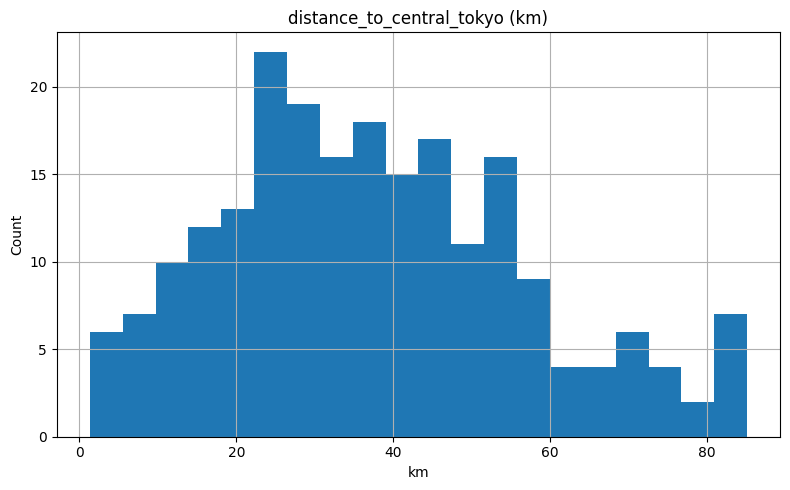

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
gdf["distance_to_central_tokyo"].hist(bins=20, ax=ax)
ax.set_title("distance_to_central_tokyo (km)")
ax.set_xlabel("km")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## Map check


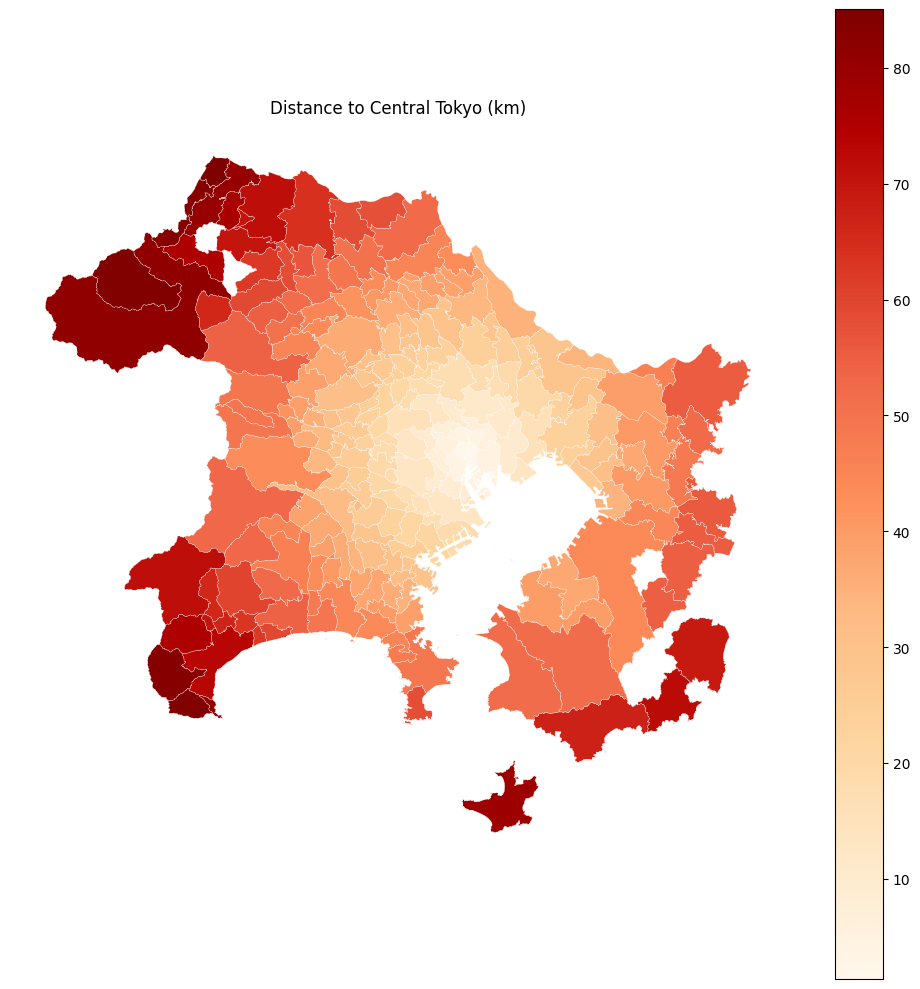

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="distance_to_central_tokyo",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
)

ax.set_title("Distance to Central Tokyo (km)")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Check Kawaguchi / Edogawa cases


In [10]:
case_df = gdf[
    gdf["N03_004"].astype(str).str.contains("川口|江戸川", na=False)
    | gdf["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][[
    "N03_001",
    "N03_004",
    "N03_005",
    "N03_007",
    "foreign_ratio",
    "log_dist_to_station_m",
    "log_median_land_price_jpy",
    "distance_to_central_tokyo",
    "log_distance_to_central_tokyo",
]].copy()

case_df


,N03_001,N03_004,N03_005,N03_007,foreign_ratio,log_dist_to_station_m,log_median_land_price_jpy,distance_to_central_tokyo,log_distance_to_central_tokyo
12,埼玉県,川口市,,11203,0.071131,5.708114,12.314932,17.129508,2.897541
131,東京都,江戸川区,,13123,0.062204,6.824599,12.894210,9.897540,2.388537


## First extended OLS


In [11]:
model_cols = [
    "foreign_ratio",
    "log_dist_to_station_m",
    "log_median_land_price_jpy",
    "log_distance_to_central_tokyo",
]

model_df = gdf[[
    "N03_007",
    "N03_001",
    "N03_004",
    "N03_005",
    "geometry",
    *model_cols,
]].copy()

for col in model_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna(subset=model_cols).copy()

X = model_df[[
    "log_dist_to_station_m",
    "log_median_land_price_jpy",
    "log_distance_to_central_tokyo",
]].copy()
X = sm.add_constant(X)

y = model_df["foreign_ratio"].copy()

extended_ols = sm.OLS(y, X).fit()

print(extended_ols.summary())


                            OLS Regression Results                            
Dep. Variable:          foreign_ratio   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     29.71
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           4.25e-16
Time:                        15:06:40   Log-Likelihood:                 576.82
No. Observations:                 218   AIC:                            -1146.
Df Residuals:                     214   BIC:                            -1132.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

## Save updated data and outputs


In [12]:
round_dir = outputs_dir / "round_09_extended_ols"
round_dir.mkdir(parents=True, exist_ok=True)

extended_prep_geojson = data_raw / "tokyo_features_v4_extended_prep.geojson"
extended_prep_csv = data_raw / "tokyo_features_v4_extended_prep.csv"

gdf.to_file(extended_prep_geojson, driver="GeoJSON")
gdf.drop(columns="geometry").to_csv(extended_prep_csv, index=False, encoding="utf-8-sig")

coef_table = pd.DataFrame({
    "term": extended_ols.params.index,
    "coef": extended_ols.params.values,
    "p_value": extended_ols.pvalues.values,
    "std_err": extended_ols.bse.values,
})

coef_table.to_csv(round_dir / "extended_ols_coefficients.csv", index=False, encoding="utf-8-sig")

with open(round_dir / "extended_ols_summary.txt", "w", encoding="utf-8") as f:
    f.write(extended_ols.summary().as_text())

fig, ax = plt.subplots(figsize=(8, 5))
gdf["distance_to_central_tokyo"].hist(bins=20, ax=ax)
ax.set_title("distance_to_central_tokyo (km)")
ax.set_xlabel("km")
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig(round_dir / "distance_to_central_tokyo_hist.png", dpi=200)
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(
    column="distance_to_central_tokyo",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    ax=ax,
)
ax.set_title("Distance to Central Tokyo (km)")
ax.set_axis_off()
plt.tight_layout()
fig.savefig(round_dir / "distance_to_central_tokyo_map.png", dpi=200)
plt.close(fig)

print("Saved:")
print(extended_prep_geojson)
print(extended_prep_csv)
print(round_dir / "extended_ols_coefficients.csv")
print(round_dir / "extended_ols_summary.txt")
print(round_dir / "distance_to_central_tokyo_hist.png")
print(round_dir / "distance_to_central_tokyo_map.png")


Saved:
E:\rsch\laborJapan\data_raw\tokyo_features_v4_extended_prep.geojson
E:\rsch\laborJapan\data_raw\tokyo_features_v4_extended_prep.csv
E:\rsch\laborJapan\outputs\round_09_extended_ols\extended_ols_coefficients.csv
E:\rsch\laborJapan\outputs\round_09_extended_ols\extended_ols_summary.txt
E:\rsch\laborJapan\outputs\round_09_extended_ols\distance_to_central_tokyo_hist.png
E:\rsch\laborJapan\outputs\round_09_extended_ols\distance_to_central_tokyo_map.png


## Memo for results log


In [13]:
memo = '''
Round 09 added distance_to_central_tokyo as the first explanatory urban-context variable.
The variable was derived from municipal centroid distance to Tokyo Station in kilometers.
This operationalizes near-core position without requiring a new external table and directly tests the current near-core interpretation anchored in cases such as Kawaguchi.
An initial extended OLS including log_distance_to_central_tokyo was estimated to generate a first post-baseline comparison.
'''.strip()

print(memo)


Round 09 added distance_to_central_tokyo as the first explanatory urban-context variable.
The variable was derived from municipal centroid distance to Tokyo Station in kilometers.
This operationalizes near-core position without requiring a new external table and directly tests the current near-core interpretation anchored in cases such as Kawaguchi.
An initial extended OLS including log_distance_to_central_tokyo was estimated to generate a first post-baseline comparison.


In [16]:
pop_path = data_raw / "tokyo_pop_dissolved.geojson"

if not pop_path.exists():
    raise FileNotFoundError(f"File not found: {pop_path}")

pop_gdf = gpd.read_file(pop_path)

print(pop_gdf.shape)
print(pop_gdf.columns.tolist())

pop_lookup = pop_gdf[["N03_007", "total_pop", "foreign_pop", "foreign_ratio"]].copy()

pop_lookup["N03_007"] = pop_lookup["N03_007"].astype(str).str.zfill(5)
gdf["N03_007"] = gdf["N03_007"].astype(str).str.zfill(5)

pop_lookup["total_pop"] = pd.to_numeric(pop_lookup["total_pop"], errors="coerce")
pop_lookup["foreign_pop"] = pd.to_numeric(pop_lookup["foreign_pop"], errors="coerce")
pop_lookup["foreign_ratio"] = pd.to_numeric(pop_lookup["foreign_ratio"], errors="coerce")

# avoid duplicated column names when merging
gdf = gdf.drop(columns=[c for c in ["foreign_ratio_from_pop"] if c in gdf.columns], errors="ignore")

gdf = gdf.merge(
    pop_lookup.rename(columns={"foreign_ratio": "foreign_ratio_from_pop"}),
    on="N03_007",
    how="left",
)

gdf[["N03_007", "foreign_ratio", "foreign_ratio_from_pop", "total_pop", "foreign_pop"]].head()

(227, 8)
['N03_007', 'N03_001', 'N03_004', 'N03_005', 'total_pop', 'foreign_pop', 'foreign_ratio', 'geometry']


,N03_007,foreign_ratio,foreign_ratio_from_pop,total_pop,foreign_pop
0,11101,0.015422,0.015422,95251,1469
1,11102,0.018455,0.018455,150366,2775
2,11103,0.027177,0.027177,124703,3389
3,11104,0.021768,0.021768,165105,3594
4,11105,0.019989,0.019989,103107,2061


In [17]:
print(gdf[["total_pop", "foreign_pop", "foreign_ratio_from_pop"]].isna().sum())

check_ratio = (gdf["foreign_ratio"] - gdf["foreign_ratio_from_pop"]).abs()
print(check_ratio.describe())
print("max abs difference:", check_ratio.max())

total_pop                 0
foreign_pop               0
foreign_ratio_from_pop    0
dtype: int64
count    218.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
dtype: float64
max abs difference: 0.0


In [18]:
metric_gdf = gdf.to_crs(gdf.estimate_utm_crs()).copy()
metric_gdf["area_sqkm"] = metric_gdf.geometry.area / 1_000_000

metric_gdf["population_density"] = (
    metric_gdf["total_pop"] / metric_gdf["area_sqkm"]
)
metric_gdf["log_population_density"] = np.log1p(metric_gdf["population_density"])

gdf["area_sqkm"] = metric_gdf["area_sqkm"].values
gdf["population_density"] = metric_gdf["population_density"].values
gdf["log_population_density"] = metric_gdf["log_population_density"].values

gdf[["area_sqkm", "total_pop", "population_density", "log_population_density"]].describe()

,area_sqkm,total_pop,population_density,log_population_density
count,218.000000,218.000000,218.000000,218.000000
mean,51.202615,166594.100917,5979.515633,8.040005
std,63.523841,157029.353313,5546.720429,1.394656
min,5.103103,2764.000000,38.802647,3.683933
25%,17.725861,56600.750000,1172.197861,7.067381
50%,30.802628,131321.000000,4775.902529,8.471545
75%,61.094166,216118.750000,8854.354242,9.088777
max,577.924713,918141.000000,22424.289950,10.017945


In [19]:
gdf[
    gdf["N03_004"].astype(str).str.contains("川口|江戸川", na=False)
    | gdf["N03_005"].astype(str).str.contains("川口|江戸川", na=False)
][[
    "N03_001",
    "N03_004",
    "N03_005",
    "N03_007",
    "total_pop",
    "area_sqkm",
    "population_density",
    "log_population_density",
    "foreign_ratio",
    "distance_to_central_tokyo",
]]

,N03_001,N03_004,N03_005,N03_007,total_pop,area_sqkm,population_density,log_population_density,foreign_ratio,distance_to_central_tokyo
12,埼玉県,川口市,,11203,606315,61.916701,9792.430638,9.189467,0.071131,17.129508
131,東京都,江戸川区,,13123,689961,48.824400,14131.479346,9.556231,0.062204,9.897540


In [20]:
model_cols_v2 = [
    "foreign_ratio",
    "log_dist_to_station_m",
    "log_median_land_price_jpy",
    "log_distance_to_central_tokyo",
    "log_population_density",
]

model_df_v2 = gdf[[
    "N03_007",
    "N03_001",
    "N03_004",
    "N03_005",
    "geometry",
    *model_cols_v2,
]].copy()

for col in model_cols_v2:
    model_df_v2[col] = pd.to_numeric(model_df_v2[col], errors="coerce")

model_df_v2 = model_df_v2.dropna(subset=model_cols_v2).copy()

X_v2 = model_df_v2[[
    "log_dist_to_station_m",
    "log_median_land_price_jpy",
    "log_distance_to_central_tokyo",
    "log_population_density",
]].copy()
X_v2 = sm.add_constant(X_v2)

y_v2 = model_df_v2["foreign_ratio"].copy()

extended_ols_v2 = sm.OLS(y_v2, X_v2).fit()

print(extended_ols_v2.summary())

                            OLS Regression Results                            
Dep. Variable:          foreign_ratio   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     22.38
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           1.94e-15
Time:                        15:41:18   Log-Likelihood:                 577.10
No. Observations:                 218   AIC:                            -1144.
Df Residuals:                     213   BIC:                            -1127.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [21]:
gdf.to_file(data_raw / "tokyo_features_v5_extended_with_density.geojson", driver="GeoJSON")
gdf.drop(columns="geometry").to_csv(
    data_raw / "tokyo_features_v5_extended_with_density.csv",
    index=False,
    encoding="utf-8-sig",
)

print(data_raw / "tokyo_features_v5_extended_with_density.geojson")
print(data_raw / "tokyo_features_v5_extended_with_density.csv")

E:\rsch\laborJapan\data_raw\tokyo_features_v5_extended_with_density.geojson
E:\rsch\laborJapan\data_raw\tokyo_features_v5_extended_with_density.csv
